<center><h1>Root Finding & Numerical Analysis</h1></center>
<center><h5>Thomas Vo</h5></center>

<center><h2>Introduction</h2></center>
In Numerical Analysis, root-finding algorithms are tools used in mathematics and computer science to locate the solutions, or "roots," of equations. These algorithms help find values of $x$ that satisfy equations of the form $f(x)=0$, especially when those equations cannot be solved analytically.

There are various root-finding algorithms, including the Bisection Method, False Position Method, Newton’s Method, and the Secant Method. These can be broadly categorized into two groups:

    Bracketing Methods (Bisection and False Position), which require an initial interval [a,b][a,b] where the function changes sign.

    Open Methods (Newton's and Secant), which do not require an interval and typically converge faster but may not always succeed without a good initial guess.

Root-finding algorithms are essential in science and engineering for solving equations that arise in modeling, simulation, and data fitting. For this project, I will focus primarily on the Bisection Method and Newton’s Method, demonstrating their behavior across different tolerance levels. I will also briefly discuss the Secant Method for comparison.


___
<center><h2>Machine Epsilon $\epsilon$</h2></center>
Before proceeding, it's important to understand the concept of machine epsilon, denoted $\epsilon$. Machine epsilon represents the smallest positive number such that $1 + \epsilon$ is distinguishable from 1 on a given computer. It quantifies the limitations of floating-point precision and plays a key role in setting stopping conditions and tolerances for numerical methods. For most 64-bit floating point numbers, the machine epsilon is approximately 
$$ \epsilon \approx 2.22 * 10^{-16} $$

Which we can confirm with numpy in python. We will use a variety of machine epsilon values like 8, 12, and 16

In [206]:
import numpy as np
#finfo = floating point information
#eps = machine epsilon
print(np.finfo(float).eps)

2.220446049250313e-16


___
<center><h2>Newton's Method</h2></center>
Newton’s Method is an open root-finding algorithm that uses both the function $f(x)$ and its derivative $f′(x)$. It updates estimates of the root using the iteration formula:

$$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

This method converges rapidly when the inital guess is close to the actual root and $f'(x) \neq 0$ but it can diverge or fail if these conditions are not met.

* Requires $f(x)$ to be differentiable near the root
* Converges quadratically near the root
* May fail to converge:
  * $f'(x)$ is zero or near zero
  * The initial guess is too far from the root

Pros & Cons:
* Very fast if the conditions are good
* Needs derivitive
* Can diverge if conditions are not met

___
<center><h2>Bisection Method</h2></center>
Bisection method is a bracketing method that finds a root of a continuous function $f(x)$ on an interval $[a,b]$ where $f(a) * f(b) < 0$. This sign change guarantees a root exist in the interval by the intermediate value theorem


Steps:
1. Compute midpoint $c = \frac{a+b}{2}$
2. Evaluate $f(c)$
3. If $|f(c)|$ is less than the tolerance, then stop. $c$ is the root
4. Otherwise, determine the subinterval
    * if $f(a)*f(b) <0$, set $b=c$
    * if $f(c)*f(b)<0$, set $a=c$
5. Repeat steps 1-4 until it converges

The Bisection method always converges as long as the initial interval brackets a root, but its convergance is linear compared to Newton's quadratic convergance, making it slower than open methods but more reliable.

___
<center><h2>Secant Method</h2></center>
The Secant method is similar to Newton's method but does not require the derivitive. Instead it approximates the derivitive using the slope of a Secant line between the two points.

$$ x_{n+1} = x_n - f(x_n) * \frac{x_n-x_{n-1}}{f(x_n)-f(x_{n-1})}$$

Pros & Cons:
* Requires two initial guesses: $x_0$ and $x_1$
* Does not require the derivitive
* Converges superlinearly (faster than Bisection but slower than Newton's)
* No guaranteed convergence
* Sensitive to bad initial guesses

___
## Code:

In [55]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
def bisection(func, a, b, tol):
    def f(x):
        return eval(func, {"x": x, "math": math})
    
    # check interval
    if f(a) * f(b) >= 0:
        print("Invalid interval: f(a) * f(b) must be negative.")
        return []

    #convert tolerance to actual value
    tolerance = 10 ** (-tol)
    initial_interval = f"[{a}, {b}]"
    iteration = 0
    guess = []

    #loop bisection algo
    while (b - a) > tolerance:
        c = (a + b) / 2
        guess.append(c)

        if f(c) * f(a) < 0:
            b = c
        else:
            a = c

        iteration += 1

    print(f"\nRoot of {func} is approximately: {c:.10f}")
    print(f"Initial interval was: {initial_interval}")
    print(f"Iterations: {iteration}")
    print(f"Tolerance used: 10^-{int(tol)}")

    return guess


___

In [117]:
def newtons(func, deriv, x0, tol):
    def f(x):
        return eval(func)

    def f_prime(x):
        return eval(deriv)

    #store intial guess and max iteration loop value
    guesses = [x0]
    iteration = 0
    max_iter = 100

    while True:
        fx = f(x0)
        dfx = f_prime(x0)

        #prevents divifng by 0 
        if abs(dfx) < 1e-14:
            print("Derivative too small, method fails.")
            break

        #update newtons loop
        x1 = x0 - fx / dfx
        guesses.append(x1)
        iteration += 1

        #check for convergence
        if abs(x1 - x0) < 10**(-tol):
            break

        #next iteration
        x0 = x1

        #iteration limit
        if iteration >= max_iter:
            print("Reached max iterations without convergence.")
            break

    print(f"\nRoot of {func} is approximately: {x1:.10f}")
    print(f"Iterations: {iteration}")
    print(f"Tolerance used: 10^-{tol}")

    return guesses


___

In [119]:
def secant(func, x0, x1, tol):
    def f(x):
        return eval(func, {"x": x, "math": math})
    
    #store intial guess, convert tolerance and max iteration value
    tol = 10 ** (-tol)
    guesses = [x0, x1]
    iteration = 0
    max_iter = 100  

    #secant method loop
    while iteration < max_iter:
        fx0 = f(x0)
        fx1 = f(x1)

        #prevent divisoion by zero
        if abs(fx1 - fx0) < 1e-14:
            print("Denominator too small — method fails.")
            break

        #secant method for next root
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        guesses.append(x2)
        iteration += 1

        #convergance check
        if abs(x2 - x1) < tol:
            break

        #update for next ioteration
        x0, x1 = x1, x2

    print(f"\nRoot of {func} is approximately: {x2:.10f}")
    print(f"Iterations: {iteration}")
    print(f"Tolerance used: 10^-{tol}")

    return guesses



Root of x**2 - 4 is approximately: 2.0000000000
Initial interval was: [0, 3]
Iterations: 42
Tolerance used: 10^-12

Root of x**2 - 4 is approximately: 2.0000000000
Iterations: 6
Tolerance used: 10^-12

Root of x**2 - 4 is approximately: 2.0000000000
Iterations: 8
Tolerance used: 10^-1e-12


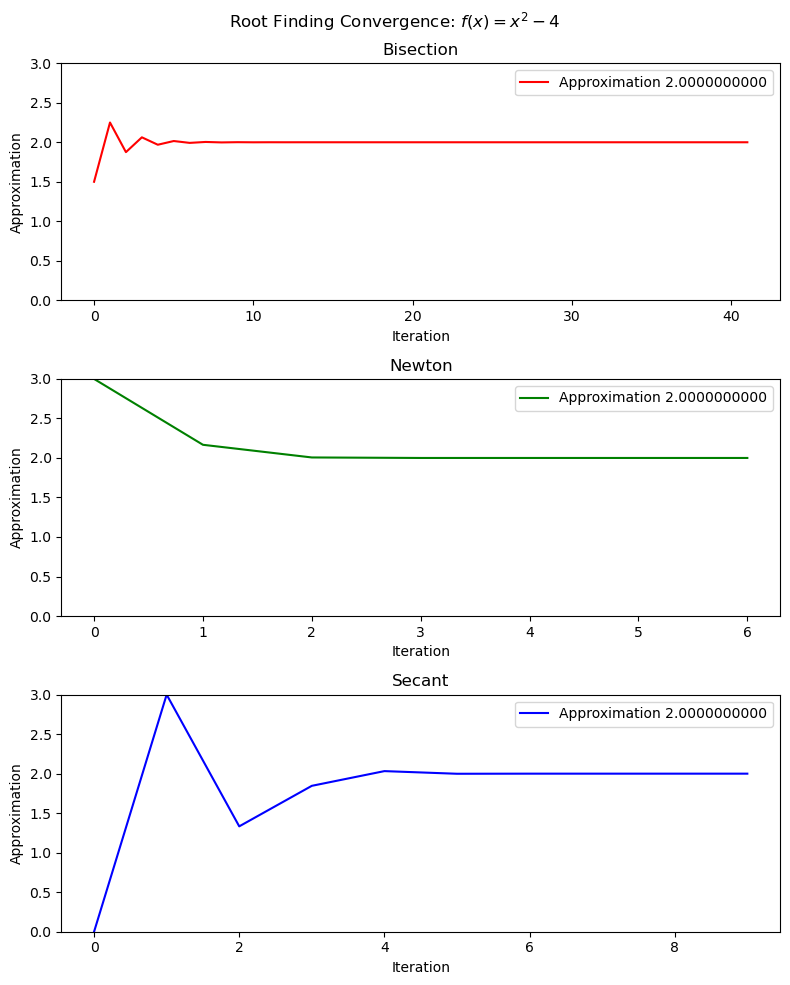

In [121]:
f = 'x**2 - 4'
f_prime = '2*x'

b = bisection(f, 0, 3, 12)
n = newtons(f, f_prime, 3.0, 12)
s = secant(f, 0, 3, 12)

fig, axs = plt.subplots(3, 1, figsize=(8, 10))

axs[0].plot(b, color='r', label=f'Approximation {b[-1]:.10f}')
axs[0].set_title("Bisection")
axs[0].legend()

axs[1].plot(n, color='g', label=f'Approximation {n[-1]:.10f}')
axs[1].set_title("Newton")
axs[1].legend()

axs[2].plot(s, color='b', label=f'Approximation {s[-1]:.10f}')
axs[2].set_title("Secant")
axs[2].legend()

for ax in axs:
    ax.set_ylabel("Approximation")
    ax.set_xlabel("Iteration")
    ax.set_ylim(min(b+n+s), max(b+n+s))

fig.suptitle("Root Finding Convergence: $f(x) = x^2 - 4$")
plt.tight_layout()
plt.show()



Root of x**3 - x - 2 is approximately: 1.5213797068
Initial interval was: [1, 2]
Iterations: 40
Tolerance used: 10^-12

Root of x**3 - x - 2 is approximately: 1.5213797068
Iterations: 4
Tolerance used: 10^-12

Root of x**3 - x - 2 is approximately: 1.5213797068
Iterations: 8
Tolerance used: 10^-1e-12


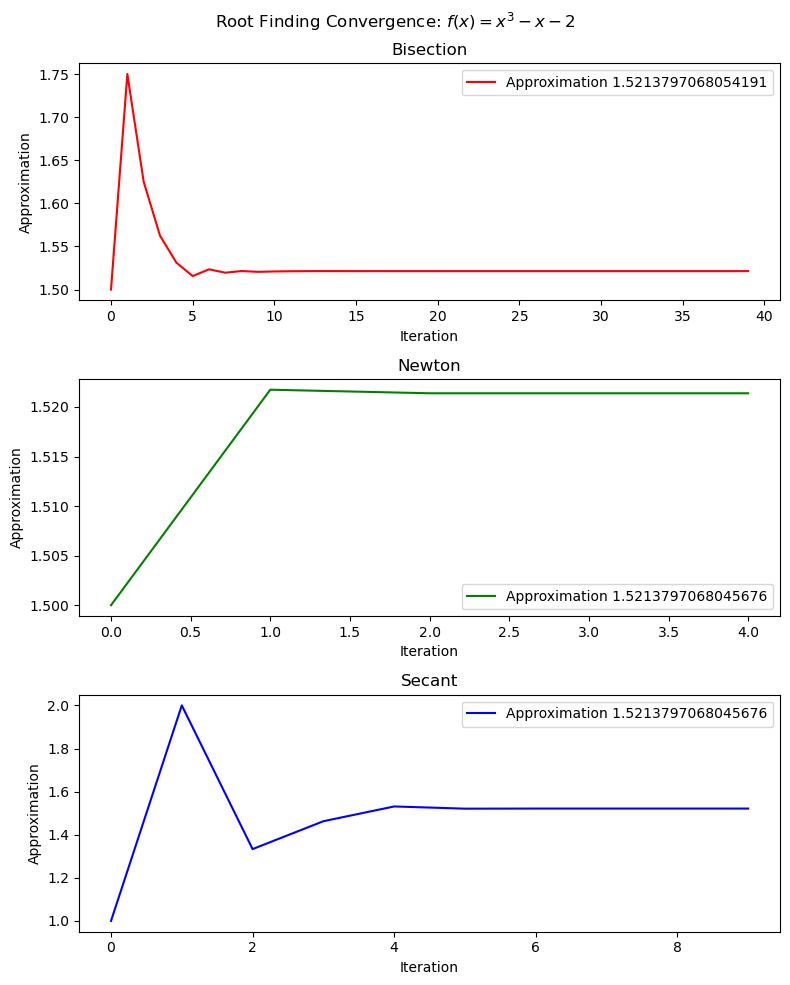

In [123]:
f = 'x**3 - x - 2'
f_prime = '3*x**2 - 1'

b = bisection(f, 1, 2, 12)
n = newtons(f, f_prime, 1.5, 12)
s = secant(f, 1, 2, 12)

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

axs[0].plot(b, color='r',label=f'Approximation {b[-1]}')
axs[0].set_title("Bisection")
axs[0].legend()

axs[1].plot(n, color='g',label=f'Approximation {n[-1]}')
axs[1].set_title("Newton")
axs[1].legend()

axs[2].plot(s, color='b',label=f'Approximation {s[-1]}')
axs[2].set_title("Secant")
axs[2].legend()

for ax in axs:
    ax.set_ylabel("Approximation")
    ax.set_xlabel("Iteration")

fig.suptitle("Root Finding Convergence: $f(x) = x^3 - x - 2$")
plt.tight_layout()
plt.show()




Root of math.tan(x) is approximately: 3.1415926536
Initial interval was: [3, 4]
Iterations: 40
Tolerance used: 10^-12

Root of math.tan(x) is approximately: 3.1415926536
Iterations: 3
Tolerance used: 10^-12

Root of math.tan(x) is approximately: 3.1415926536
Iterations: 6
Tolerance used: 10^-1e-12


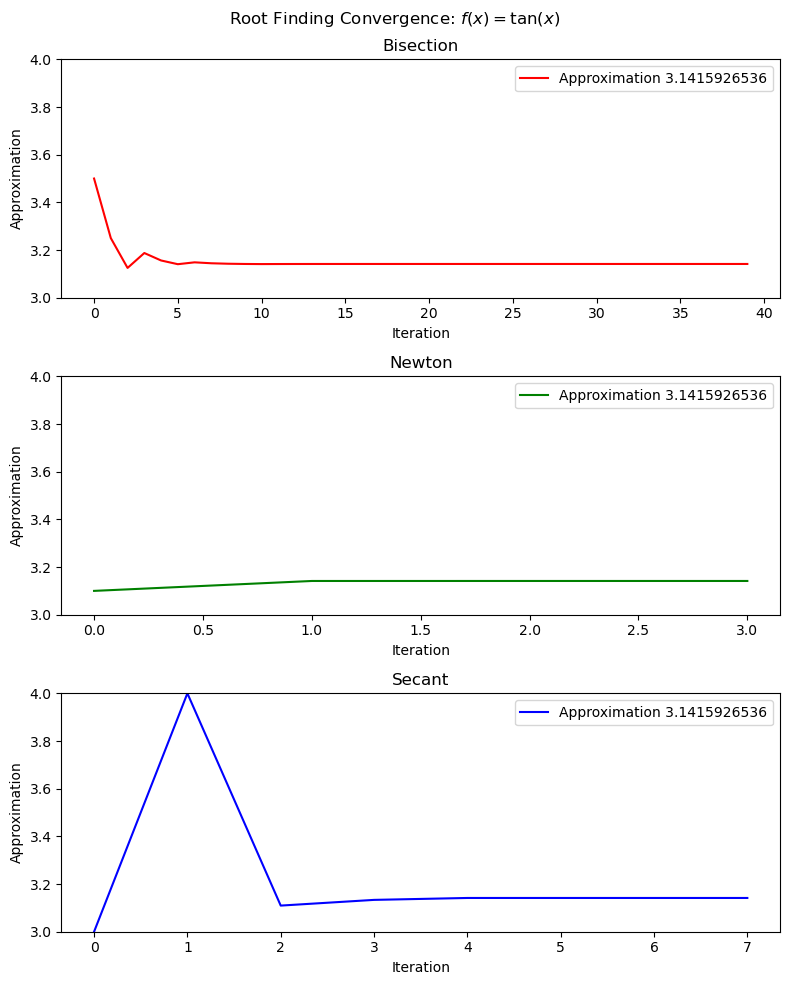

In [125]:
f = 'math.tan(x)'
f_prime = '1 / math.cos(x)**2'

b = bisection(f, 3, 4, 12)
n = newtons(f, f_prime, 3.1, 12)
s = secant(f, 3, 4, 12)

fig, axs = plt.subplots(3, 1, figsize=(8, 10))

axs[0].plot(b, color='r', label=f'Approximation {b[-1]:.10f}')
axs[0].set_title("Bisection")
axs[0].legend()

axs[1].plot(n, color='g', label=f'Approximation {n[-1]:.10f}')
axs[1].set_title("Newton")
axs[1].legend()

axs[2].plot(s, color='b', label=f'Approximation {s[-1]:.10f}')
axs[2].set_title("Secant")
axs[2].legend()


for ax in axs:
    ax.set_ylabel("Approximation")
    ax.set_xlabel("Iteration")
    ax.set_ylim(min(b+n+s), max(b+n+s))

fig.suptitle("Root Finding Convergence: $f(x) = \\tan(x)$")
plt.tight_layout()
plt.show()


For this function, you can see that all 3 methods converges to the same value, but the thing that differs between them is the amount of iterations with bisection taking 40 iterations at a tolerance of $10^-12$, while Newton's and Secant took 3 and 6 iterations. This is due to ourgood initial guess, but if I were to give a bad initial guess the results would be dramatically different.


Root of math.tan(x) is approximately: 1.5707963268
Initial interval was: [1.55, 1.58]
Iterations: 35
Tolerance used: 10^-12

Root of math.tan(x) is approximately: 0.0000000000
Iterations: 15
Tolerance used: 10^-12

Root of math.tan(x) is approximately: 0.0000000000
Iterations: 16
Tolerance used: 10^-1e-12


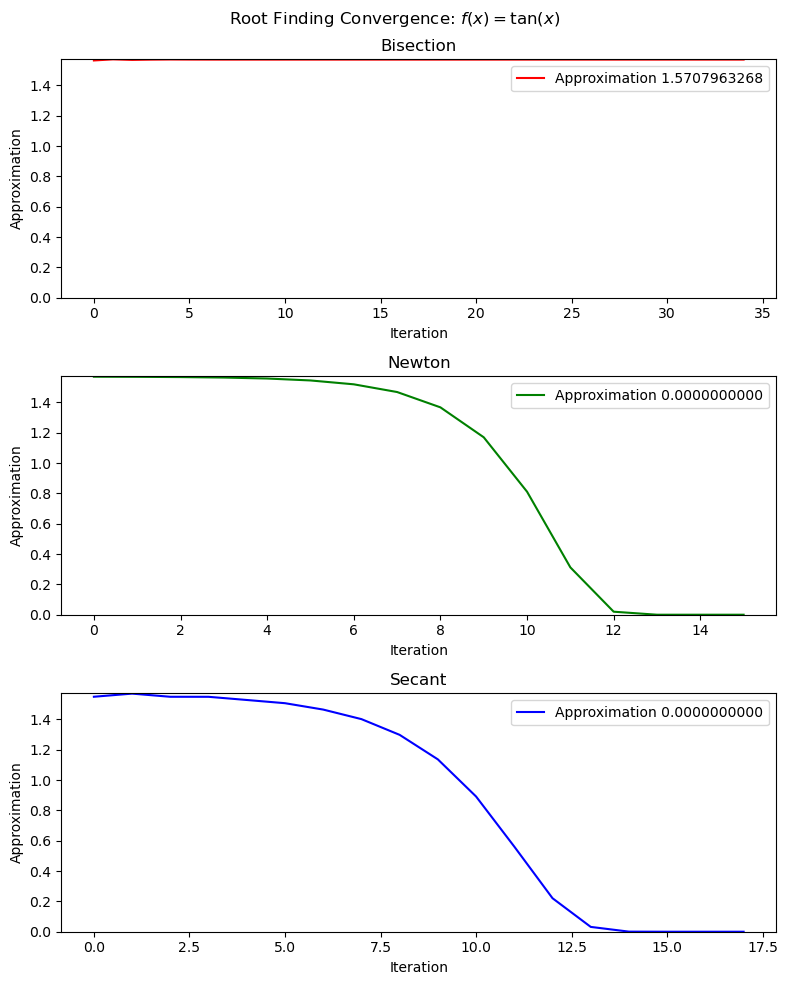

In [169]:
f = 'math.tan(x)'
f_prime = '1 / math.cos(x)**2'

b = bisection(f, 1.55, 1.58, 12)
n = newtons(f, f_prime, 1.57, 12)
s = secant(f, 1.55, 1.5706, 12)

fig, axs = plt.subplots(3, 1, figsize=(8, 10))

axs[0].plot(b, color='r', label=f'Approximation {b[-1]:.10f}')
axs[0].set_title("Bisection")
axs[0].legend()

axs[1].plot(n, color='g', label=f'Approximation {n[-1]:.10f}')
axs[1].set_title("Newton")
axs[1].legend()

axs[2].plot(s, color='b', label=f'Approximation {s[-1]:.10f}')
axs[2].set_title("Secant")
axs[2].legend()


for ax in axs:
    ax.set_ylabel("Approximation")
    ax.set_xlabel("Iteration")
    ax.set_ylim(min(b+n+s), max(b+n+s))

fig.suptitle("Root Finding Convergence: $f(x) = \\tan(x)$")
plt.tight_layout()
plt.show()


This graph above shows what happens with you give:


Bisection method, a risky narrow interval near $\frac{\pi}{2}$, it still converged but it still required 35 iterations to achieve the tolerance of $10^{-12}$


Newton's Method a bad initial guess of near $x = \frac{\pi}{2}$, Newton's method did not converge to the expected root of $\pi$ but instead converged to zero. This shows the high sensitivity of Newton's method's initial guess.


Secant method, using $x_0 = 1.5$ and $x_1 = 1.5706$, the secant method failed to converge. The guesses remained trapped in the steep region of the vertical asyymptote at $x = \frac{\pi}{2}$, where $tan(x)$ rapidly increases. This shows that even if the function is continuous on the interval, extreme slope changes can make the secant method unreliable. 
___

### Method Comparison
To compare the 3 root finding methods we have tested, we saw the difference convergance rates, efficiency and reliability. 
* The Bisection method
  * Bracket method
  * Linear Ccnvergence
  * Very reliable
  * Slow with a lot of iterations
* Newton's Method
  * Open method
  * Quadratic convergence
  * Sensitive to initial guess
  * Derivitive cannot be zero
  * Fast, only if conditions are good
* Secant Method
  * Open Method
  * Superlinear convergence
  * Less stable than Newton's but more efficient than Bisection
  * Fast, no limitations with derivitives

For functions like $x*2-4$, all methods performed well with Newton's converging the fastest. This was due to the function being continuous and differentiable. While functions like $tan(x)$, Newton's and Secant methods were more prone to failure due to the steep slopes and discontinuities. $tan(x)$ has discontinuities at $pi/2$, if the guess is close in Newton's Method $f'(x) = sec^2(x)$ becomes very large, leading to division by large numbers. And in the secant method, if either $x_0$ or $x_1$ is near the asymtote, the function will be unstable, but without using the derivitive, the secant method relies on the slope between the two points, this slope could steep or zero which could lead to inaccurate results. Both Newton's and Secant require a good initial guess, if not it will likely diverge.

<center><h2>Conclusion</h2></center>
In this project, we explored the performance and limitations of three classic root-finding algorithms, Bisection, Newton's, and Secant methods on both well behaved and problematic functions. While the three methods can converge effectively under ideal conditions, our experiement showed their distinct behaviors when given poor initial conditions. Using $tan(x)$ as a test case exposed key vulnerabilities, Newton and Secant methods struggled near asymtotes and were highly sensitive to poor initial guess, sometimes diverging or converging to incorrect roots. On the other hand, Bisection method was slower and more iteration heavy but it showed the reliability of the method even given poor intervals. This experiement proves that the choice of method for numerical analysis should depend on the nature of the function and the reliability of the initial guess/interval. 


Do you prioritize efficiency, accuracy, or reliability?

Whatever your answer is will help you determine which method to use. If speed is critical and the function is smooth, your best choice would be Newton's method. If reliability is most important than the Bisection Method is the safer choice. And if you want to use Newton's method but the derivitive is zero then your choice is Secant. 

There is one more method that I haven't covered but I will mention here. The False position method, it uses the same interval as bisection but instead of splitting the interval at the midpoint, it uses a secant method to estimate the next guess. The pros of this method is it often converges faster than bisection and maintains the pros of bracketing methods. But in ideal cases, it is still slower than Newton's or Secant.